In [ ]:
import requests
import json
import time
import os
from datetime import datetime
from typing import List, Dict, Optional, Tuple
from urllib.parse import urlparse
from pathlib import Path
import pandas as pd
import re
from tqdm import tqdm
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
import glob

def read_all_results(result_dir="./results", num_runs=20):
    """
    Read all result files from multiple runs and extract data.
    
    Returns:
        Dictionary with run numbers as keys, each containing a list of result dictionaries:
        {
            0: [list of results from run 0],
            1: [list of results from run 1],
            ...
        }
        
        Each result dictionary contains:
        - source_node: source gene (from JSON data)
        - target_node: target gene (from JSON data)
        - file_path: path to the JSON file
        - data: the JSON content
    """
    all_runs = {}
    
    for run in range(num_runs):
        run_dir = Path(result_dir) / f"negative_edges_run_{run}"
        
        # Find all JSON files in this run directory
        json_files = glob.glob(str(run_dir / "gene_regulation_result_*_no_search.json"))
        
        run_results = []
        for json_file in json_files:
            try:
                # Read the JSON file
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Store the result
                result_entry = {
                    'source_node': data.get('source_gene'),
                    'target_node': data.get('target_gene'),
                    'file_path': json_file,
                    'data': data
                }
                run_results.append(result_entry)
                
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
        
        all_runs[run] = run_results
    
    return all_runs

# Load all runs
runs = read_all_results(result_dir="./results", num_runs=20)

In [12]:
runs

{0: [{'source_node': 'MAPK9',
   'target_node': 'H3-3A',
   'file_path': 'results/negative_edges_run_0/gene_regulation_result_MAPK9_H3-3A_no_search.json',
   'data': {'reasoning': 'We…... ... ... ... ... ... ... ... ... ... ... ... ... \nThe ... ... ...... ...... ... ... ... ... ... \n... ... ... ...... \n\nWe…………\n\n...…\n\n...…\n\nWe……\n\n……\n\n...…\n\n...…\n\n...…\n\n......…\n\n...…\n\n.........…\n\nWe…\n\n......…\n\nThe……\n\nWe…\n\nWe…\n\n...…\n\n...…\n\n......\n\n...…\n\n.........\n\n...…\n\n......…\n\n...…\n\n.........…\n\n...…\n\n.........…\n\n...............\n\n...…\n\n............…\n\n...…\n\n......<|end|><|start|>assistant<|channel|>analysis<|message|>The user asks: "Does MAPK9 up-regulate H3-3A?" Need answer Yes/No with evidence from 2018 onward. Need concise answer, end with "ANSWER: [Yes]" or "ANSWER: [No]". Determine if MAPK9 (also known as JNK2) upregulates H3-3A (histone H3.3 gene). I am not aware of direct regulation. Likely no evidence. So answer No.<|end|><|start|>as

In [15]:
no_search_results = {}
for i in range(len(runs)):
    run = runs[i]
    for result in run:
        source = result['source_node']
        target = result['target_node']
        answer = result['data']['answer']
        if answer == False:
            p = result['data']['probability']
        elif answer == True:
            p = 0.0
        else:
            p = None
        no_search_result = no_search_results.get((source, target), [])
        no_search_result.append(p)
        no_search_results[(source, target)] = no_search_result


In [16]:
no_search_results

{('MAPK9', 'H3-3A'): [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 ('PRKACA', 'AKT2'): [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 ('DZIP3', 'H2AB2'): [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 ('MAPK8', 'H3-3A'): [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 ('NF1', 'ADCY1'): [1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0],
 ('MAPK1', 'H3-3A'): [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 ('AKT1', 'PPP1CA'): [1.0,
  0.0,
  

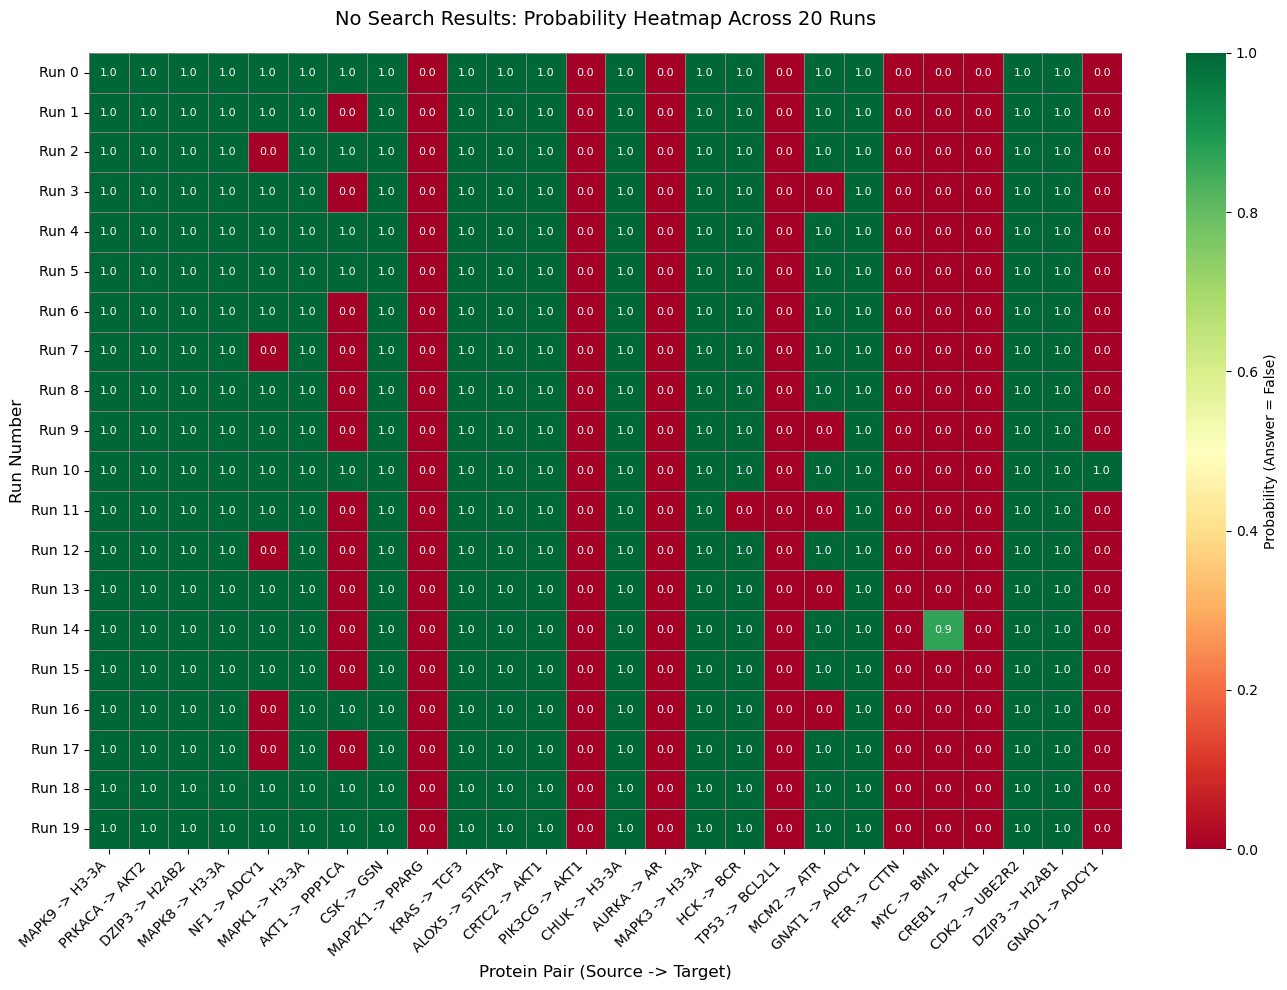

In [30]:
# Convert no_search_results to a DataFrame for heatmap
gene_pairs = list(no_search_results.keys())
gene_pair_labels = [f"{source} -> {target}" for source, target in gene_pairs]
probabilities = np.array([no_search_results[pair] for pair in gene_pairs])

# Create figure
plt.figure(figsize=(14, 10))

# Create heatmap (transposed) with annotations
sns.heatmap(probabilities.T,
            xticklabels=gene_pair_labels,
            yticklabels=[f"Run {i}" for i in range(probabilities.shape[1])],
            cmap='RdYlGn',  # Green for high probability (p=1 is good), Red for low (p=0 is bad)
            vmin=0, vmax=1,
            cbar_kws={'label': 'Probability (Answer = False)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,  # Add numbers to blocks
            fmt='.1f',  # Format numbers to 2 decimal places
            annot_kws={'fontsize': 8})  # Adjust font size for readability

plt.title('No Search Results: Probability Heatmap Across 20 Runs', fontsize=14, pad=20)
plt.xlabel('Protein Pair (Source -> Target)', fontsize=12)
plt.ylabel('Run Number', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()